# Artificial Neural Networks 

## Inspired by Biological Neural Networks

<div style="text-align:center">
<img src="images/nn_biological.jpeg" alt="plot" width="600" />
</div>

Neural Networks (NN) receive many external inputs, these inputs are weighted and produce an output based.

A few details : 
- The output of a biological NN in an Action Potential.
- The weights associated with each input is related to the physical properties of the synapse (connection between neurons) and its location. 
- The overall influence of the inputs over the output is equivalent to a **weighted sum** 
- Each neuron can receive input from thousands or other neurons (or itself), and influence other thousands of neurons. 

These principles inspired the development of Artificial Neural Networks (ANN). However, biological NN are very complex chemical/biological systems; in contrast, ANNs are simple mathematical models that can grown in size. 

### From Linear Models to Artificial Neural Networks
Assume that you have a linear model of the form 

$$
\hat{y} = b_0 + x_1\omega_{1} + x_2\omega_{2} + \cdots + x_m\omega_{m} 
$$


A simple way to *extend* that linear model is to apply a nonlinearity (called Activation) that transforms the output. 
$$
y = g\left(b_0 + x_1\omega_{1} + x_2\omega_{2} + \cdots + x_m\omega_{m}\right) \\
\hat{y} = g(z) 
$$

Where $g(\bullet)$ is a nonlinearity. The here are some commonly used nonlinearity (x-axis are the input and y-axis are the output)
<div style="text-align:center">
<img src="images/activation_functions2.png" alt="plot" width="500" />
</div>

In principle, an ANN is a linear system extended to include a nonlinearity. This basic component is called an artificial neuron. 
<div style="text-align:center">
<img src="images/ann_example.jpg" alt="plot" width="300" />
</div>

ANN are then created by stacking multiple neurons; for instance, this is a ANN with 5 neurons
<div style="text-align:center">
<img src="images/single_hidden_layer.jpg" alt="plot" width="300" />
</div>

You can also increase the number of layers; for instance, this is an ANN with two hidden layers, and different number of neurons per layer. 
<div style="text-align:center">
<img src="images/two_hidden_layer.png" alt="plot" width="300" />
</div>


ANNs can grow to be very complex, note that every line in the diagram correspond to a weight ($\omega$) that must be estimated using .... Gradient Descent.  
<div style="text-align:center">
<img src="images/large_ann.png" alt="plot" width="600" />
</div>


We won't go into the details of estimating the model parameters, but is based on the same principle that we discuss for linear regression. There are very efficient python libraries to estimate these parameters. 

## A silly example

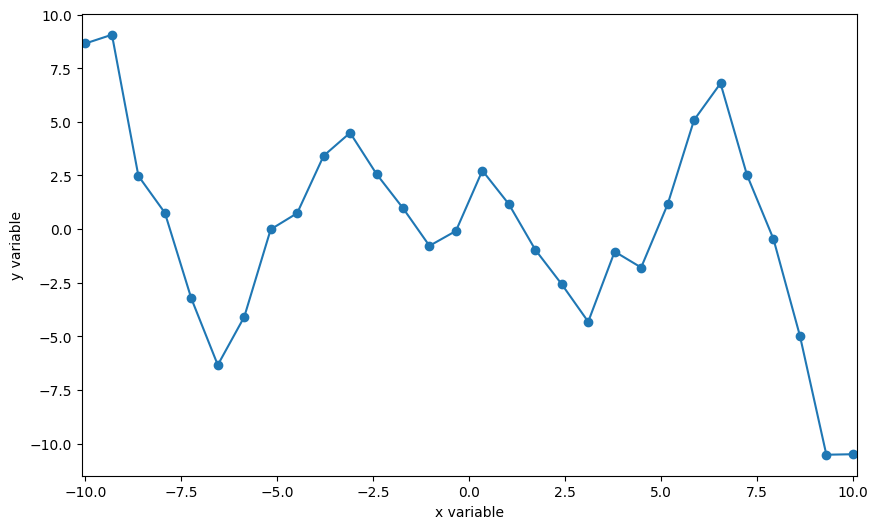

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(-10,10,30)
y_values = x_values*np.cos(x_values) + 1*np.random.randn(x_values.size) #a cosine with some noise
x_values = np.expand_dims(x_values,1)
y_values = np.expand_dims(y_values,1)
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o-', label= 'True Relation')
plt.xlabel('x variable')
plt.ylabel('y variable')
plt.xlim([-10.1,10.1])
plt.show()

The goal is to create a simple ANN that given the $x$ and $y$ data, can help us predict the value of $y$ for each value of $x$. 

Lets first try wit a linear regression model

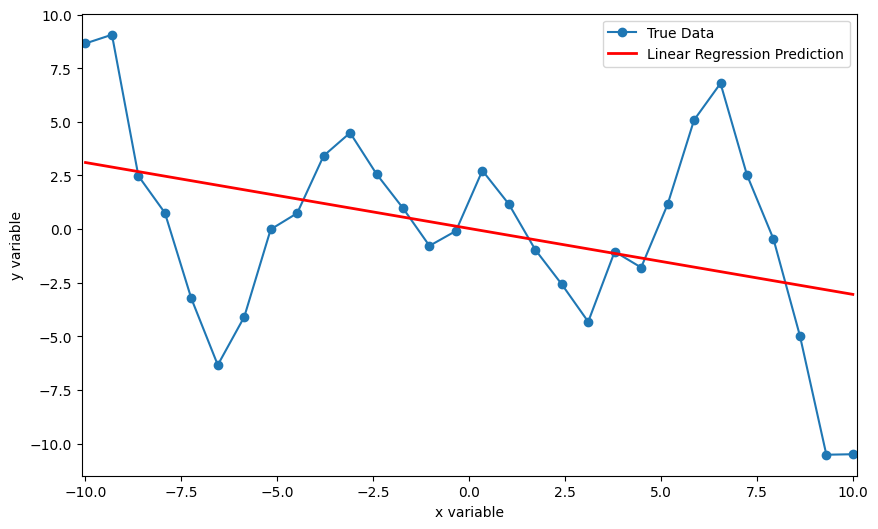

In [3]:
from sklearn.linear_model import LinearRegression

# Fit linear regression model
model = LinearRegression()
model.fit(x_values, y_values)

# Make predictions
y_pred = model.predict(x_values)

# Plot the data and predictions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o-', label='True Data')
plt.plot(x_values, y_pred, 'r-', label='Linear Regression Prediction', linewidth=2)
plt.xlabel('x variable')
plt.ylabel('y variable')
plt.xlim([-10.1, 10.1])
plt.legend()
plt.show()

Clearly a linear model didn't work well. 

Lets try a neural network with one layer and one neuron 

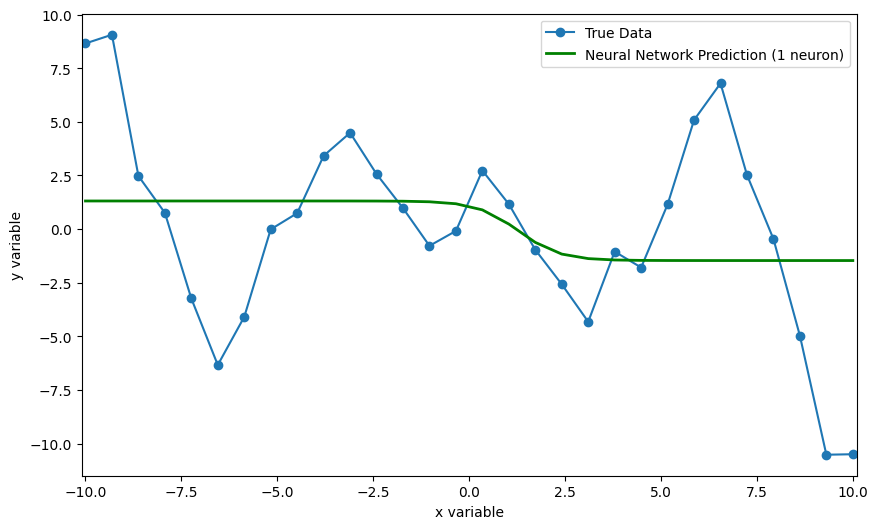

In [7]:
from sklearn.neural_network import MLPRegressor

# Fit neural network with one hidden layer and one neuron
nn_model = MLPRegressor(hidden_layer_sizes=(1,), max_iter=10000, random_state=42, activation = 'tanh')
nn_model.fit(x_values, y_values.ravel()) # Flatten y_values to 1D array for training

# Make predictions
y_pred_nn = nn_model.predict(x_values)

# Plot the data and predictions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o-', label='True Data')
plt.plot(x_values, y_pred_nn, 'g-', label='Neural Network Prediction (1 neuron)', linewidth=2)
plt.xlabel('x variable')
plt.ylabel('y variable')
plt.xlim([-10.1, 10.1])
plt.legend()
plt.show()

That didn't do much, lets try with one layer and 10 neurons. 

The default activation is `Relu`, we can try other activation functions to get a smoother output. We will use `tanh`.

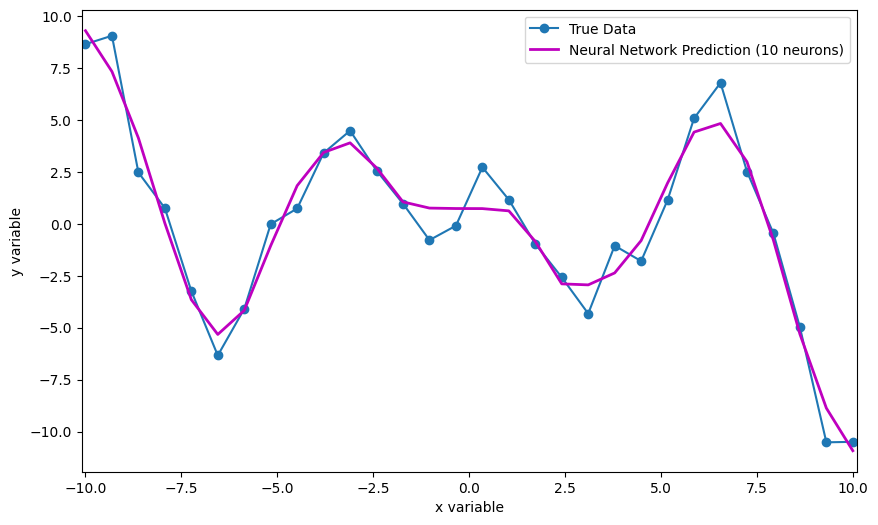

In [20]:
# Fit neural network with one hidden layer and 10 neurons
nn_model_10 = MLPRegressor(hidden_layer_sizes=(10,), max_iter=10000, random_state=42, activation='tanh')
nn_model_10.fit(x_values, y_values.ravel())

# Make predictions
y_pred_nn10 = nn_model_10.predict(x_values)

# Plot the data and predictions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o-', label='True Data')
plt.plot(x_values, y_pred_nn10, 'm-', label='Neural Network Prediction (10 neurons)', linewidth=2)
plt.xlabel('x variable')
plt.ylabel('y variable')
plt.xlim([-10.1, 10.1])
plt.legend()
plt.show()

This looks much better. We basically have ten simple models (neurons) working together to predict the output. Each input ($x$) is transformed by these nonlinear models to generate an output. 

<div style="text-align:center">
<img src="images/10layers.png" alt="plot" width="600" />
</div>


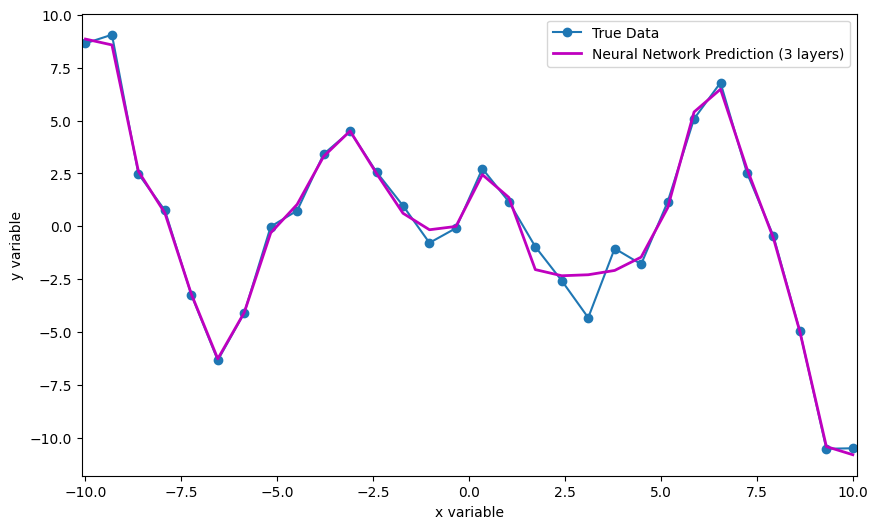

In [27]:
# Now let's fit a neural network with 3 layers and different neurons per layer
nn_model_3layers = MLPRegressor(hidden_layer_sizes=(4,5,5,4), max_iter=10000, random_state=42, activation='tanh')
nn_model_3layers.fit(x_values, y_values.ravel())


# Make predictions
y_pred_nn3layers = nn_model_3layers.predict(x_values)

# Plot the data and predictions
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'o-', label='True Data')
plt.plot(x_values, y_pred_nn3layers, 'm-', label='Neural Network Prediction (3 layers)', linewidth=2)
plt.xlabel('x variable')
plt.ylabel('y variable')
plt.xlim([-10.1, 10.1])
plt.legend()
plt.show()

<div style="text-align:center">
<img src="images/Multilayers.png" alt="plot" width="600" />
</div>

A few details about ANN:
1. ANN are called Universal Approximation models, that is, an infinity large ANN can be used to approximate any relationship between input and output data
2. This universal approximation only works in the support 

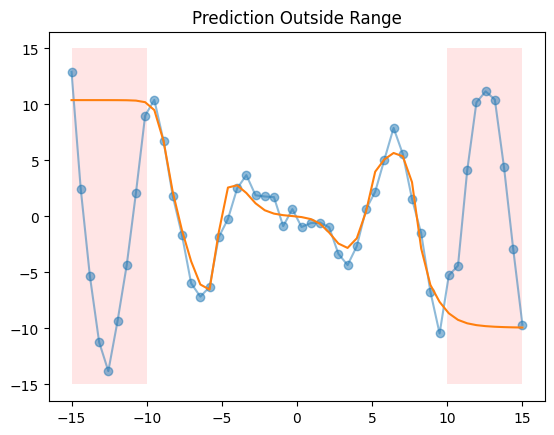

In [26]:
from matplotlib.patches import Rectangle
x_values = np.linspace(-15,15,50)
y_values = x_values*np.cos(x_values) +  1*np.random.randn(x_values.size)

plt.gca().add_patch(Rectangle((-15, -15), 5, 30, facecolor = 'red', alpha = 0.1))
plt.gca().add_patch(Rectangle((10, -15), 5, 30, facecolor = 'red', alpha = 0.1))
plt.plot(x_values,y_values,'o-', label='Measured Data', alpha = 0.5)
out = nn_model_3layers.predict(x_values.reshape(-1,1))
plt.plot(x_values, out, label='Prediction')
plt.title('Prediction Outside Range')
plt.show()

When ANN become *VERY* larger (millions of parameters), it is necessary to use specialized methods so ensure converge of the gradient descent algorithm used to find the model's parameters. Libraries as PyTorch and TensorFlow have special methods to train these large models. 

## Example - ANN for classification

Neural networks are non-linear models that can be used to separate non-linearly separable classes

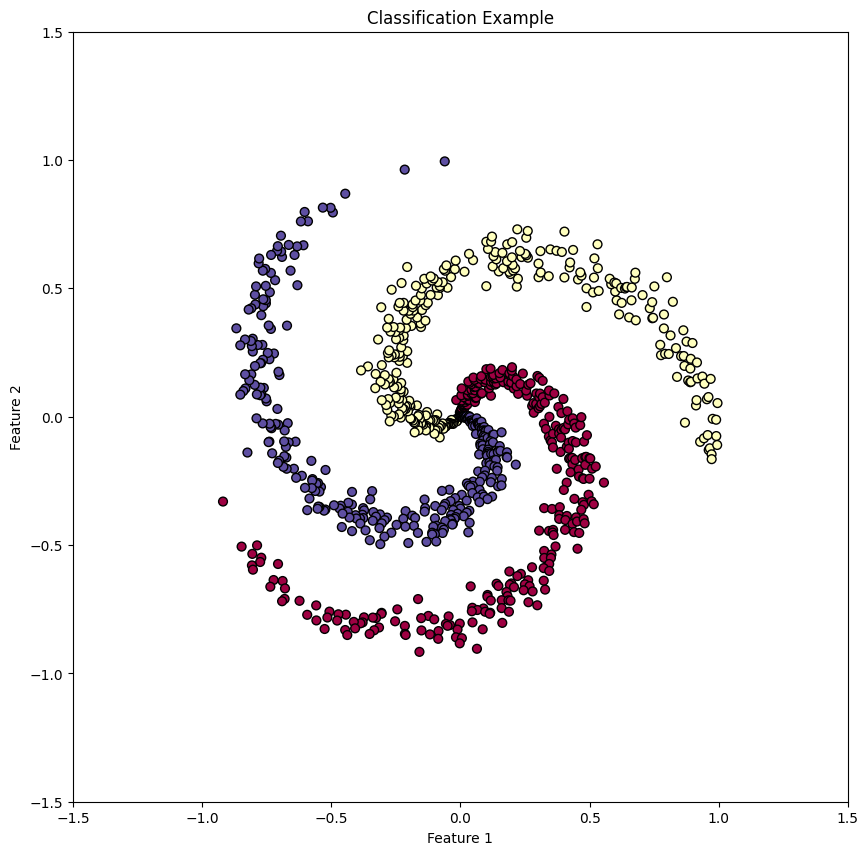

In [29]:
np.random.seed(0)
N = 300
D = 2
K = 3
X = np.zeros((N*K,2))
Y = np.zeros(N*K, dtype = 'uint8')
for j in range(K):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
    X[ix,:] = np.c_[r*np.sin(t), r*np.cos(t)]
    Y[ix] = j
    
fig = plt.figure(figsize=(10,10))
plt.scatter(X[:, 0], X[:, 1], edgecolors='k', c=Y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1.5,1.5])
plt.ylim([-1.5,1.5])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Classification Example')
plt.show()

Lets try a logistic regression model first!

Logistic Regression training accuracy: 0.548


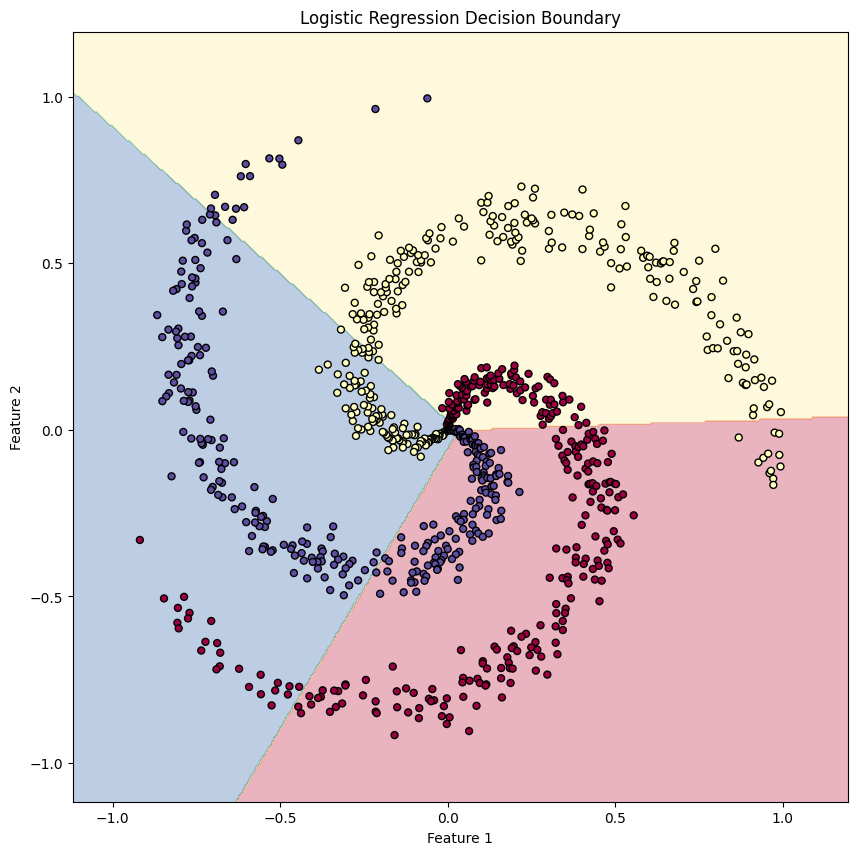

In [30]:
from sklearn.linear_model import LogisticRegression

# Train multinomial logistic regression
logreg_model = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
logreg_model.fit(X, Y)

# Training accuracy
train_acc = logreg_model.score(X, Y)
print(f"Logistic Regression training accuracy: {train_acc:.3f}")

# Plot decision boundary
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = logreg_model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 10))
plt.contourf(xx, yy, Z, alpha=0.35, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors="k", s=25, cmap=plt.cm.Spectral)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.show()

It didn't work :(

Lets try a RandomFores!

Random Forest training accuracy: 0.996


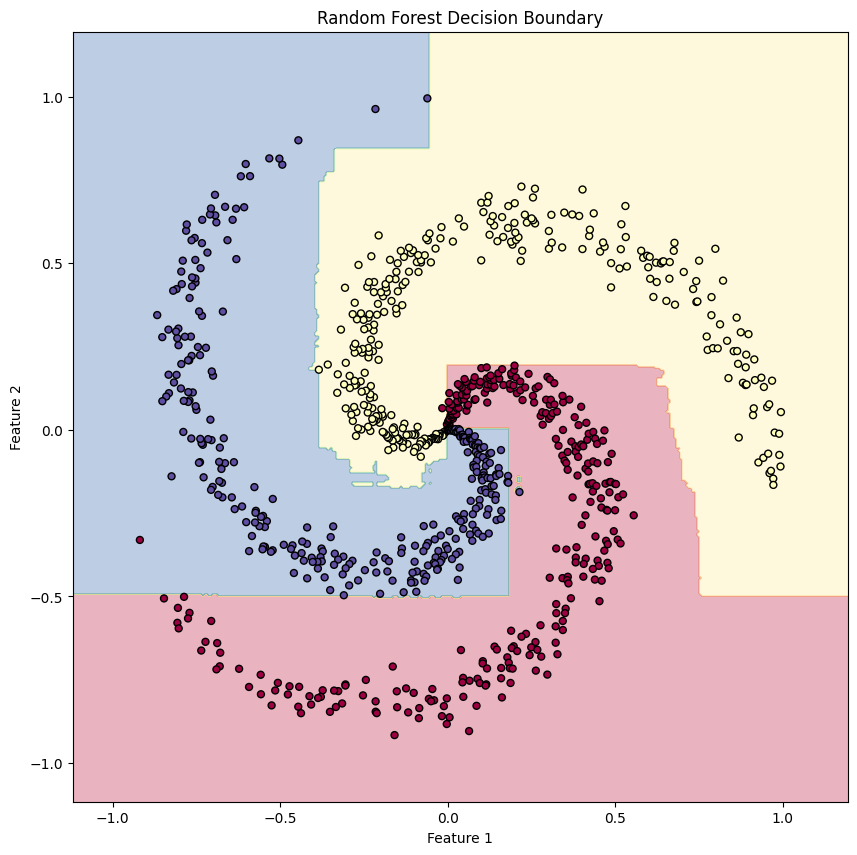

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest classifier
rf_clf = RandomForestClassifier(
	n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
	random_state=42,
	n_jobs=-1
)
rf_clf.fit(X, Y)

# Training accuracy
rf_train_acc = rf_clf.score(X, Y)
print(f"Random Forest training accuracy: {rf_train_acc:.3f}")

# Decision boundary
Z_rf = rf_clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 10))
plt.contourf(xx, yy, Z_rf, alpha=0.35, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors="k", s=25, cmap=plt.cm.Spectral)
plt.title("Random Forest Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.show()

It worked!

Lets try a ANN now with `tanh` nonlinearity

MLP training accuracy: 0.994


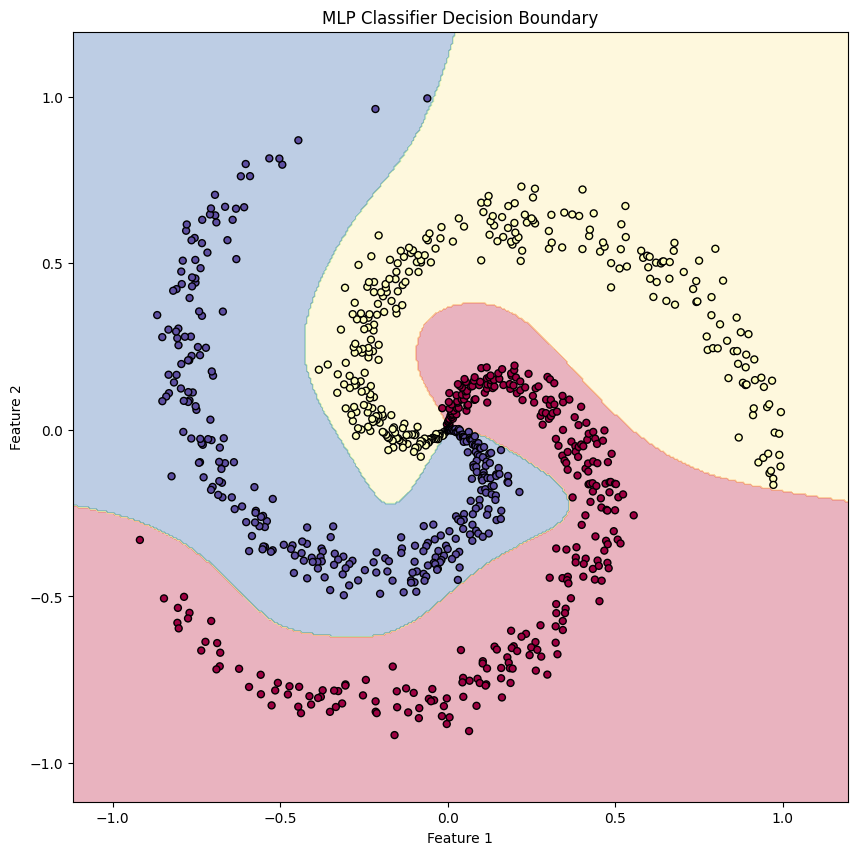

In [36]:
from sklearn.neural_network import MLPClassifier

# Train MLP classifier
mlp_clf = MLPClassifier(
	hidden_layer_sizes=(5, 5),
	activation="tanh",
	solver="adam",
	max_iter=5000,
	random_state=42
)
mlp_clf.fit(X, Y)

# Training accuracy
mlp_train_acc = mlp_clf.score(X, Y)
print(f"MLP training accuracy: {mlp_train_acc:.3f}")

# Decision boundary
Z_mlp = mlp_clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 10))
plt.contourf(xx, yy, Z_mlp, alpha=0.35, cmap=plt.cm.Spectral)
plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors="k", s=25, cmap=plt.cm.Spectral)
plt.title("MLP Classifier Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.show()

It worked as well !!!

## Activity 

Split the data into training and validation, train a Random Forest and a NN with the training data and evaluate using the validation data. Which model gives the best results for the validation data? 